<a href="https://colab.research.google.com/github/adljna/ProjectA-Group3-KematianAliKhamenei/blob/main/Content%20Scraping%20%26%20Preprocessing/Kompas/2_Kompas_PreprocessingNews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Analisis Sentimen Berita Kematian Ali Khamenei - Kompas**

Notebook ini merupakan adaptasi dari notebook Detik, disesuaikan untuk scraping artikel dari **Kompas.com** beserta seluruh subdomainnya (`internasional`, `nasional`, `regional`, `bola`, `english`, `cahaya`, `video`).

* **Instalasi Library**: Menginstal semua library Python yang dibutuhkan.
* **Impor Library**: Mengimpor modul dan fungsi yang diperlukan.
* **Data Scraping**: Membaca CSV link artikel Kompas dan melakukan scraping dengan logika per subdomain.
* **Data Preprocessing**: Cleaning, tokenisasi, stopword removal, stemming, deteksi bahasa.
* **Analisis Sentimen**: TextBlob + GoogleTranslator (ID ke EN).
* **Visualisasi (Word Cloud)**: Word Cloud sentimen Positif dan Negatif.
* **Ekspor Hasil**: Menyimpan ke `analyzed_articles_kompas.csv`.

#**(1) Instalasi Library**

Instalasi semua library untuk scraping, NLP, dan analisis sentimen.

In [ ]:
!pip install beautifulsoup4 requests pandas lxml

!pip uninstall icu -y
!pip uninstall polyglot -y
!pip uninstall pyicu -y

!pip install polyglot pycld2 pyicu morfessor
!pip install deep-translator
!pip install Sastrawi
!pip install stanza
!pip install nltk
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.3/126.3 kB 11.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.2/268.2 kB 24.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 67.3 MB/s eta 0:00:00
  Created wheel for polyglot: filename=polyglot-16.7.4-py2.py3-none-any.whl size=52563 sha256=8a287979814ca2ed0da8fa41b4b6c3e99928a53ecc3be5f480eaa4239dc6be9e
  Stored in directory: /root/.cache/pip/wheels/c7/5e/28/47349211ec1f91379f41ed10bc2520f7071ecfb6cbe182f6fe
  Created wheel for pyicu: filename=pyicu-2.16.2-cp312-cp312-linux_x86_64.whl size=2720233 sha256=da264523dcd87c5ca0e78f1ba2e7b332c8abdac3adffe08744e9da694cbdb896
  Stored in directory: /root/.cache/pip/wheels/25/f3/cd/4923c874cedf8cdb8608035f48bb726fa040a98a66e2b13cea
Successfully built polyglot pyicu
   ━━━━━━━━━━━━

#**(2) Impor Library**

Mengimpor semua modul yang diperlukan.

In [ ]:
import io
import string
import re
import time
from collections import defaultdict, Counter
from urllib.parse import urlparse

import pandas as pd
import numpy as np

import requests
from bs4 import BeautifulSoup
from google.colab import files

import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import stanza

from textblob import TextBlob
from deep_translator import GoogleTranslator

import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

#**(3) Data Scraping**

Membaca CSV berisi link artikel Kompas dan melakukan scraping konten.

### Struktur URL Kompas yang Ditangani

| Subdomain | Selector HTML Utama |
|---|---|
| `www`, `internasional`, `nasional`, `regional`, `bola` | `div.read__content` |
| `cahaya.kompas.com` | `div.col-bs9-inner` / `div[data-content]` |
| `video.kompas.com` | `div.video__description` / meta description |
| `english.kompas.com` | `div.read__content` / `div#content` |

In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Saving kompas_khamenei_articles.csv to kompas_khamenei_articles.csv


In [ ]:
try:
    links_df = pd.read_csv(io.BytesIO(uploaded[filename]))
    if 'Link' in links_df.columns:
        urls = links_df['Link'].tolist()
        print(f"Berhasil memuat {len(urls)} URL dari '{filename}'.")
        print('\nContoh URL:')
        for u in urls[:5]:
            print(' ', u)
    else:
        print("Error: Kolom 'Link' tidak ditemukan dalam CSV.")
        urls = []
except Exception as e:
    print(f'Terjadi kesalahan: {e}')
    urls = []

Berhasil memuat 100 URL dari 'kompas_khamenei_articles.csv'.

Contoh URL:
  https://www.kompas.com/global/read/2026/03/02/065000070/setelah-ali-khamenei-pergi
  https://cahaya.kompas.com/aktual/26C14141821890/profil-mojtaba-khamenei-pemimpin-tertinggi-iran-pengganti-ayatollah-ali-khamenei
  https://nasional.kompas.com/read/2026/03/09/04000071/megawati-ali-khamenei-dan-keadilan-dunia
  https://www.kompas.com/cekfakta/read/2026/03/12/192000582/-hoaks-foto-gibran-pernah-mengunjungi-ali-khamenei
  https://www.kompas.com/cekfakta/read/2026/03/02/170700882/-hoaks-foto-jenazah-ali-khamenei-di-reruntuhan


In [ ]:
def get_article_type(url):
    # Menentukan tipe artikel Kompas berdasarkan subdomain URL.
    parsed = urlparse(url)
    domain = parsed.netloc.lower()
    if 'cahaya.kompas.com' in domain:
        return 'cahaya'
    elif 'video.kompas.com' in domain:
        return 'video'
    elif 'english.kompas.com' in domain:
        return 'english'
    else:
        return 'standard'  # www, internasional, nasional, regional, bola


def scrape_kompas(url):
    # Scraping utama untuk semua subdomain Kompas.
    # Setiap tipe subdomain memiliki selector HTML yang berbeda.
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                      '(KHTML, like Gecko) Chrome/124.0.4472.124 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
        'Accept-Language': 'id-ID,id;q=0.9,en-US;q=0.8,en;q=0.7',
        'Referer': 'https://www.google.com/',
        'Accept-Encoding': 'gzip, deflate, br',
        'Connection': 'keep-alive',
    }

    try:
        response = requests.get(url, headers=headers, timeout=20)

        if response.status_code != 200:
            return {
                'url': url, 'title': None, 'content': None,
                'article_type': get_article_type(url),
                'error': f'HTTP {response.status_code}'
            }

        soup = BeautifulSoup(response.content, 'lxml')
        article_type = get_article_type(url)

        # --- Ekstrak judul ---
        # Prioritas: og:title > h1.read__title > h1 umum > <title>
        title = None
        og_title = soup.find('meta', property='og:title')
        if og_title and og_title.get('content'):
            title = og_title['content'].strip()
        if not title:
            h1 = (soup.find('h1', class_='read__title') or
                  soup.find('h1', class_='article__title') or
                  soup.find('h1'))
            if h1:
                title = h1.get_text(strip=True)
        if not title:
            tag_title = soup.find('title')
            if tag_title:
                title = tag_title.get_text(strip=True)

        # --- Ekstrak konten berdasarkan tipe subdomain ---
        content = None
        paragraphs = []

        if article_type == 'cahaya':
            # cahaya.kompas.com - format jurnalisme warga/aktual
            # Selector utama: div.col-bs9-inner atau div[data-content]
            content_div = (
                soup.find('div', class_='col-bs9-inner') or
                soup.find('div', attrs={'data-content': True}) or
                soup.find('div', class_='article__body') or
                soup.find('article')
            )
            if content_div:
                for el in content_div.find_all(['script', 'style', 'figure', 'aside']):
                    el.decompose()
                for el in content_div.find_all(
                    class_=re.compile(r'ads|iklan|caption|photo|related|widget', re.I)
                ):
                    el.decompose()
                paragraphs = content_div.find_all('p')
            else:
                paragraphs = soup.find_all('p')

        elif article_type == 'video':
            # video.kompas.com - konten berupa deskripsi video
            content_div = (
                soup.find('div', class_='video__description') or
                soup.find('div', class_='video__body') or
                soup.find('div', class_='detail__body')
            )
            if content_div:
                paragraphs = content_div.find_all('p')
            # Fallback: meta description (jika halaman video minim teks)
            if not paragraphs:
                meta_desc = (soup.find('meta', attrs={'name': 'description'}) or
                             soup.find('meta', property='og:description'))
                if meta_desc and meta_desc.get('content'):
                    content = meta_desc['content'].strip()

        elif article_type == 'english':
            # english.kompas.com - format lama (/read/xml/) atau baru
            content_div = (
                soup.find('div', class_='read__content') or
                soup.find('div', id='content') or
                soup.find('div', class_='article-content') or
                soup.find('article')
            )
            if content_div:
                for el in content_div.find_all(['script', 'style', 'figure', 'aside']):
                    el.decompose()
                paragraphs = content_div.find_all('p')
            else:
                paragraphs = soup.find_all('p')

        else:
            # standard: www, internasional, nasional, regional, bola.kompas.com
            # Selector utama Kompas standar: div.read__content
            content_div = (
                soup.find('div', class_='read__content') or
                soup.find('div', class_='article__content') or
                soup.find('div', class_='detail__body-text') or
                soup.find('article') or
                soup.find('div', class_='content')
            )
            if content_div:
                # Hapus elemen non-artikel: iklan, foto, berita terkait
                for el in content_div.find_all(['script', 'style', 'figure', 'aside']):
                    el.decompose()
                for el in content_div.find_all(
                    class_=re.compile(
                        r'ads|iklan|photo|caption|related|recommendation|widget|author|tag',
                        re.I
                    )
                ):
                    el.decompose()
                paragraphs = content_div.find_all('p')
            else:
                # Fallback jika selector utama tidak ditemukan
                paragraphs = soup.find_all('p')

        # Gabungkan paragraf menjadi teks
        if paragraphs and not content:
            content = '\n'.join([
                p.get_text(separator=' ', strip=True)
                for p in paragraphs if p.get_text(strip=True)
            ])

        # Bersihkan newline berlebih
        if content:
            content = re.sub(r'\n{3,}', '\n\n', content).strip()

        return {
            'url': url,
            'title': title,
            'content': content,
            'article_type': article_type,
            'error': None
        }

    except Exception as e:
        return {
            'url': url, 'title': None, 'content': None,
            'article_type': get_article_type(url),
            'error': str(e)
        }

In [ ]:
# Jalankan scraping untuk semua URL
data = []
if urls:
    print(f'Memulai scraping {len(urls)} artikel...\n')
    for i, url in enumerate(urls):
        result = scrape_kompas(url)
        data.append(result)
        if (i + 1) % 10 == 0 or (i + 1) == len(urls):
            sukses = sum(1 for d in data if d['content'])
            print(f'[{i+1}/{len(urls)}] Berhasil: {sukses} | Gagal: {i+1 - sukses}')
        time.sleep(0.5)  # Jeda untuk menghindari rate-limiting
else:
    print('Tidak ada URL untuk di-scrape.')

df_article = pd.DataFrame(data)
print('\nHasil scraping:')
print(df_article[['url', 'title', 'article_type', 'error']].head(10))
total = len(df_article)
berhasil = df_article['content'].notna().sum()
print(f'\nTotal: {total} | Berhasil: {berhasil} | Gagal: {total - berhasil}')

Memulai scraping 100 artikel...

[10/100] Berhasil: 10 | Gagal: 0
[20/100] Berhasil: 20 | Gagal: 0
[30/100] Berhasil: 30 | Gagal: 0
[40/100] Berhasil: 40 | Gagal: 0
[50/100] Berhasil: 50 | Gagal: 0
[60/100] Berhasil: 60 | Gagal: 0
[70/100] Berhasil: 70 | Gagal: 0
[80/100] Berhasil: 80 | Gagal: 0
[90/100] Berhasil: 90 | Gagal: 0
[100/100] Berhasil: 96 | Gagal: 4

Hasil scraping:
                                                 url  \
0  https://www.kompas.com/global/read/2026/03/02/...   
1  https://cahaya.kompas.com/aktual/26C1414182189...   
2  https://nasional.kompas.com/read/2026/03/09/04...   
3  https://www.kompas.com/cekfakta/read/2026/03/1...   
4  https://www.kompas.com/cekfakta/read/2026/03/0...   
5  https://www.kompas.com/global/read/2026/03/22/...   
6  https://www.kompas.com/tren/read/2026/03/09/08...   
7  https://www.kompas.com/tren/read/2026/03/09/16...   
8  https://nasional.kompas.com/read/2026/03/04/21...   
9  https://www.kompas.com/global/read/2025/02/07/...   

  

In [ ]:
print('Distribusi tipe artikel:')
print(df_article['article_type'].value_counts())

df_article.to_csv('scraped_articles_kompas.csv', index=False)
print("\nScraping mentah disimpan ke 'scraped_articles_kompas.csv'")

Distribusi tipe artikel:
article_type
standard    83
video       10
english      4
cahaya       3
Name: count, dtype: int64

Scraping mentah disimpan ke 'scraped_articles_kompas.csv'


#**(4) Data Preprocessing**

Membersihkan dan mempersiapkan teks artikel:
1. `clean_text`: Hapus URL, mention, angka, tanda baca, spasi berlebih.
2. `tokenize_text`: Tokenisasi.
3. `remove_stopwords`: Hapus stopwords Bahasa Indonesia.
4. `stem_text`: Stemming (Sastrawi).
5. Deteksi bahasa (Polyglot).

In [ ]:
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_text(text):
    if not isinstance(text, str):
        return []
    return word_tokenize(text)

list_stopwords = nltk.corpus.stopwords.words('indonesian')

def remove_stopwords(tokens, stopwords_list):
    return [word for word in tokens if word not in stopwords_list and word.strip() != '']

def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

In [ ]:
from polyglot.text import Text

df_article['text_cleaned'] = df_article['content'].fillna('').apply(clean_text)
df_article['tokens'] = df_article['text_cleaned'].apply(tokenize_text)
df_article['tokens_no_stop'] = df_article['tokens'].apply(lambda x: remove_stopwords(x, list_stopwords))
df_article['tokens_stemmed'] = df_article['tokens_no_stop'].apply(stem_text)
df_article['text_final'] = df_article['tokens_stemmed'].apply(lambda x: ' '.join(x))

print('DataFrame setelah Preprocessing:')
print(df_article[['content', 'text_cleaned', 'tokens', 'tokens_no_stop', 'tokens_stemmed', 'text_final']].head())

print('\nDeteksi Bahasa (5 baris pertama):')
for index, row in df_article.head(5).iterrows():
    try:
        text_sample = row['content'] if pd.notna(row['content']) else ''
        text_obj = Text(text_sample)
        if text_obj.language.code:
            print(f"Row {index} [{row['article_type']}]: Code={text_obj.language.code}, Name={text_obj.language.name}")
        else:
            print(f'Row {index}: Deteksi bahasa gagal.')
    except Exception as e:
        print(f'Row {index}: Error - {e}')

DataFrame setelah Preprocessing:
                                             content  \
0  WAJAH politik Iran dan Timur Tengah pada hari ...   
1  Profil Mojtaba Khamenei, Pemimpin Tertinggi Ir...   
2  KEMATIAN Pemimpin Tertinggi Iran, Ali Khamenei...   
3  Berdasarkan verifikasi Kompas.com sejauh ini, ...   
4  Berdasarkan verifikasi Kompas.com sejauh ini, ...   

                                        text_cleaned  \
0  wajah politik iran dan timur tengah pada hari ...   
1  profil mojtaba khamenei pemimpin tertinggi ira...   
2  kematian pemimpin tertinggi iran ali khamenei ...   
3  berdasarkan verifikasi kompascom sejauh ini in...   
4  berdasarkan verifikasi kompascom sejauh ini in...   

                                              tokens  \
0  [wajah, politik, iran, dan, timur, tengah, pad...   
1  [profil, mojtaba, khamenei, pemimpin, tertingg...   
2  [kematian, pemimpin, tertinggi, iran, ali, kha...   
3  [berdasarkan, verifikasi, kompascom, sejauh, i...   
4  [berdasark

#**(5) Analisis Sentimen**

Menganalisis sentimen menggunakan TextBlob. Teks Indonesia diterjemahkan dulu ke Bahasa Inggris dengan GoogleTranslator. Teks panjang dibagi per chunk untuk menghindari batas API.

In [ ]:
def analyze_long_text_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series([None, None])

    if len(text) < 4500:
        try:
            translated = GoogleTranslator(source='id', target='en').translate(text)
            blob = TextBlob(translated)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])
        except Exception as e:
            print(f'Error teks pendek: {e}')
            return pd.Series([None, None])
    else:
        try:
            max_chunk = 4500
            chunks = [text[i:i+max_chunk] for i in range(0, len(text), max_chunk)]
            translated_chunks = []
            for i, chunk in enumerate(chunks):
                if i > 0:
                    time.sleep(0.5)
                translated_chunks.append(
                    GoogleTranslator(source='id', target='en').translate(chunk)
                )
            full_translated = ' '.join(translated_chunks)
            blob = TextBlob(full_translated)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])
        except Exception as e:
            print(f'Error teks panjang: {e}')
            return pd.Series([None, None])

def get_sentiment_label(polarity):
    if polarity is None:
        return 'Undefined'
    elif polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Netral'

In [ ]:
df_article[['polarity', 'subjectivity']] = df_article['text_final'].apply(analyze_long_text_sentiment)
df_article['polarity'].fillna(0, inplace=True)
df_article['sentiment_label'] = df_article['polarity'].apply(get_sentiment_label)

print('DataFrame dengan hasil sentimen:')
print(df_article[['url', 'article_type', 'title', 'polarity', 'subjectivity', 'sentiment_label']].head(10))

print('\nDistribusi sentimen:')
print(df_article['sentiment_label'].value_counts())

print('\nDistribusi sentimen per tipe artikel:')
print(df_article.groupby(['article_type', 'sentiment_label']).size().unstack(fill_value=0))

Error teks pendek: kompascom ayatollah ali khamenei pimpin tinggi iran jabat iran ucap ali khamenei mutlak nobat orang daftar  orang pengaruh dunia  forbes anggap otoritas politik kuat kuat presiden negara baca iran bantah laku serang kapal tanker minyak tuduh israel iran jabat presiden iran main peran kunci revolusi iran dinasti pahlavi mohammad reza shah pahlavi guling grand ruhollah khomeini diri partai republik islam capai kuat politik orang percaya ambil alih jabat presiden bunuh mohammadali raja jabat posisi milik jiwa miskin tubuh lengkap martabat korban revolusi islam baca lawan iran teroris atlet korea selatan maaf ali khamenei khamenei lahir juli anak delapan saudara pasang seyyed javad khamenei khadijeh mirdamadi mashhad kota suci iran ikut jejak ayah ulama pilih mudah iran perintah shah mohammad reza pahlavi raja sekuler pandang agama kuno curiga khamenei ulama muda usia mehdi khalaji tulis biografi ayatullah lansir bbc status buat jalan tumbuh mudah anak pantar ejek seraga

/tmp/ipykernel_5384/261292103.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_article['polarity'].fillna(0, inplace=True)


#**(6) Visualisasi (Word Cloud)**

Word Cloud untuk kata paling sering muncul pada artikel bersentimen Positif dan Negatif.

Artikel Positif : 58
Artikel Negatif : 6


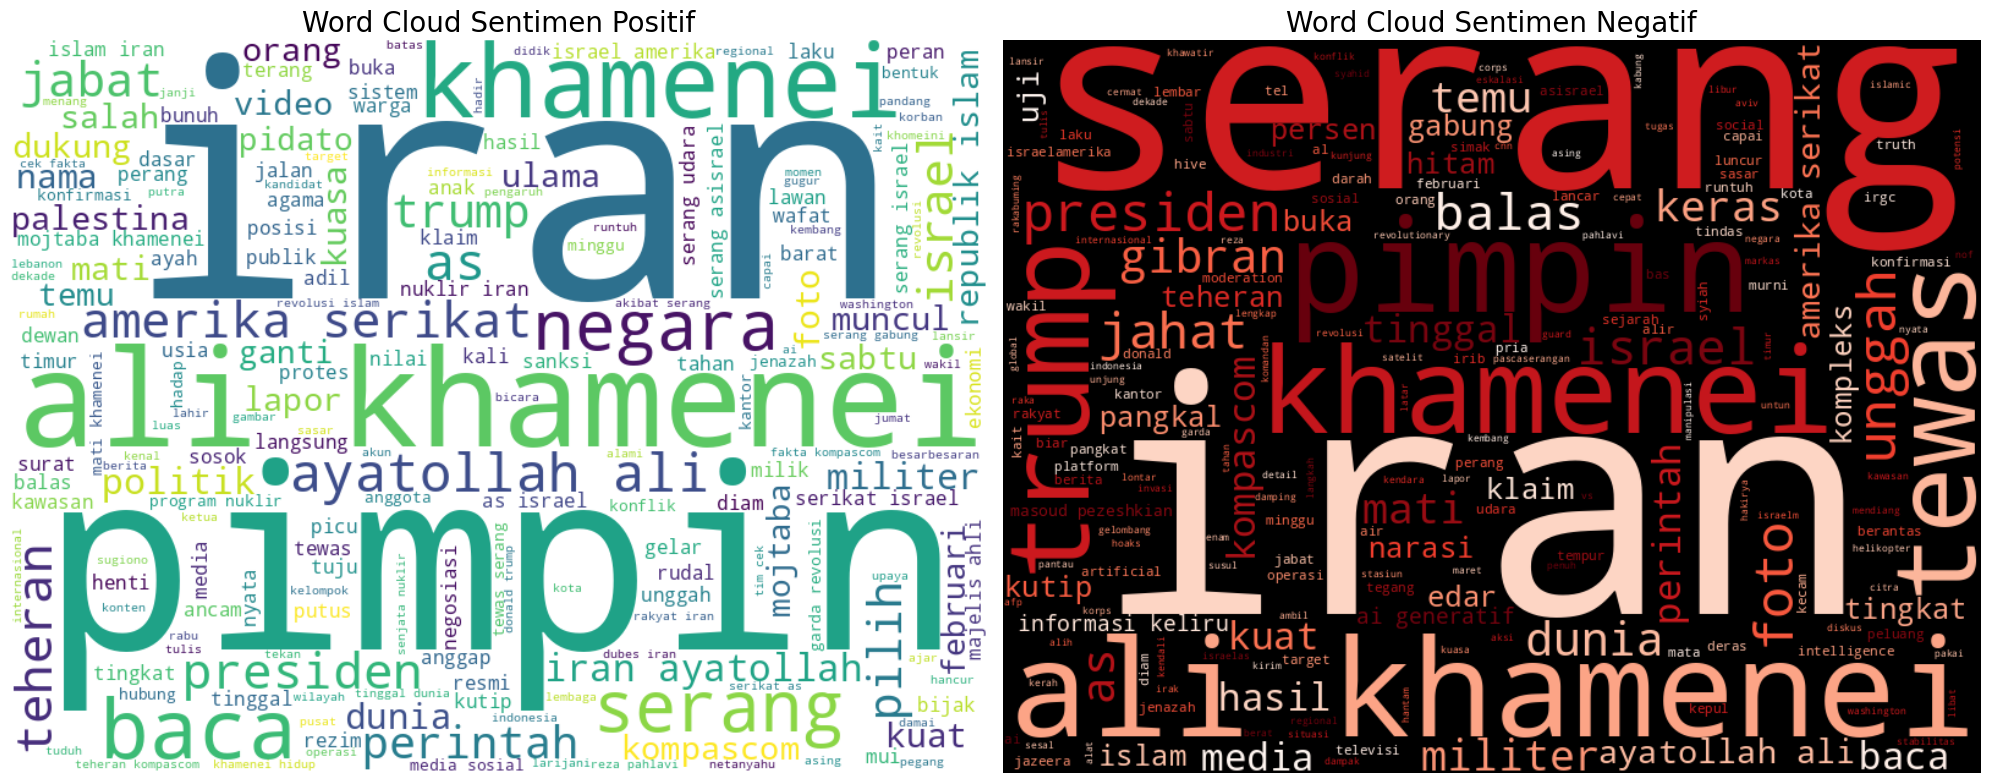

In [ ]:
positive_df = df_article[df_article['sentiment_label'] == 'Positive']
negative_df = df_article[df_article['sentiment_label'] == 'Negative']

print(f'Artikel Positif : {len(positive_df)}')
print(f'Artikel Negatif : {len(negative_df)}')

positive_text = ' '.join(positive_df['text_final'])
negative_text = ' '.join(negative_df['text_final'])

plt.figure(figsize=(20, 10))

if positive_text.strip():
    plt.subplot(1, 2, 1)
    wc_pos = WordCloud(
        stopwords=list_stopwords, width=800, height=600,
        background_color='white', colormap='viridis'
    ).generate(positive_text)
    plt.imshow(wc_pos, interpolation='bilinear')
    plt.title('Word Cloud Sentimen Positif', fontsize=20)
    plt.axis('off')
else:
    print('Tidak ada teks positif untuk Word Cloud.')

if negative_text.strip():
    plt.subplot(1, 2, 2)
    wc_neg = WordCloud(
        stopwords=list_stopwords, width=800, height=600,
        background_color='black', colormap='Reds'
    ).generate(negative_text)
    plt.imshow(wc_neg, interpolation='bilinear')
    plt.title('Word Cloud Sentimen Negatif', fontsize=20)
    plt.axis('off')
else:
    print('Tidak ada teks negatif untuk Word Cloud.')

plt.tight_layout()
plt.show()

#**(7) Ekspor Hasil**

Menyimpan DataFrame akhir ke CSV.

In [ ]:
df_article_export = df_article.drop(columns=['article_type', 'error'], errors='ignore')
df_article_export.to_csv('analyzed_articles_kompas.csv', index=False)
print("Hasil analisis disimpan ke 'analyzed_articles_kompas.csv'")
print(f'Total baris: {len(df_article_export)}')
print(df_article_export[['url', 'title', 'polarity', 'sentiment_label']].head(10))

Hasil analisis disimpan ke 'analyzed_articles_kompas.csv'
Total baris: 100
                                                 url article_type  \
0  https://www.kompas.com/global/read/2026/03/02/...     standard   
1  https://cahaya.kompas.com/aktual/26C1414182189...       cahaya   
2  https://nasional.kompas.com/read/2026/03/09/04...     standard   
3  https://www.kompas.com/cekfakta/read/2026/03/1...     standard   
4  https://www.kompas.com/cekfakta/read/2026/03/0...     standard   
5  https://www.kompas.com/global/read/2026/03/22/...     standard   
6  https://www.kompas.com/tren/read/2026/03/09/08...     standard   
7  https://www.kompas.com/tren/read/2026/03/09/16...     standard   
8  https://nasional.kompas.com/read/2026/03/04/21...     standard   
9  https://www.kompas.com/global/read/2025/02/07/...     standard   

                                               title  polarity sentiment_label  
0                         Setelah Ali Khamenei Pergi -0.017268          Netral  
1  